## Бізнес-контекст
Компанія TextMind Analytics досліджує, як користувачі описують свої враження про бренд у соціальних мережах.
Команді потрібно зрозуміти, які слова і вирази близькі за змістом, щоб групувати тексти за темами.
Ваше завдання — побудувати векторні уявлення слів і дослідити їхні семантичні зв'язки за допомогою моделей Word2Vec і GloVe.

## Завдання 1
Підготуйте корпус текстів.
 - Зберіть невеликий набір (10-15 речень) з відгуками або твітами про продукт.
 - Приведіть усі тексти до нижнього регістру, видаліть пунктуацію.
 - Розділіть тексти на токени і збережіть результат у список списків (кожен підсписок — одне речення).
 - Перевірте кількість речень і середню довжину в словах.



In [1]:
fname = "feedbacks6_2.txt"

In [2]:
import re
def prepare(phrase: str) -> str:
    return re.sub('\n', ' ', re.sub(r'([^\w\s])+', '', phrase.lower()))

In [3]:
with open(fname) as f:
    feedbacks =[prepare(item) for item in f.readlines()]
print(feedbacks[:3])


['this product has good performance and great build quality ', 'the design is nice and the overall experience is amazing ', 'i had a good experience using this product every day ']


In [4]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download(["punkt_tab", "stopwords", "wordnet"])
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

tokens = [[w for w in word_tokenize(fb) if not w in stop_words] for fb in feedbacks]
print(*tokens[:3], sep='\n')

for i in range(0, len(tokens), 5):
    print(i+1, "Середня довжина слів:", sum(len(w) for w in tokens[i]) / len(tokens[i]))

['product', 'good', 'performance', 'great', 'build', 'quality']
['design', 'nice', 'overall', 'experience', 'amazing']
['good', 'experience', 'using', 'product', 'every', 'day']
1 Середня довжина слів: 6.5
6 Середня довжина слів: 8.2
11 Середня довжина слів: 6.5
16 Середня довжина слів: 7.8
21 Середня довжина слів: 7.0
26 Середня довжина слів: 6.0


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bezsh_km76\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bezsh_km76\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bezsh_km76\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Завдання 2
Побудуйте модель Word2Vec.
 - Використовуйте бібліотеку gensim.models.Word2Vec.
 - Параметри: vector_size = 100, window = 5, min_count = 1, sg = 1.
 - Навчіть модель на підготовленому корпусі.
 - Виведіть вектор слова good (якщо воно є в корпусі).



In [5]:
from gensim.models import Word2Vec
model = Word2Vec(vector_size = 100, window = 5, min_count=1, sg = 1,
                sentences=tokens
)
word = "good"
try:
    vector = model.wv[word]
    print(vector)
except:
    print(f"Word '{word}' not found")

[ 8.4057690e-05  3.0940641e-03 -6.8101864e-03 -1.3308452e-03
  7.6585924e-03  7.3239766e-03 -3.6371038e-03  2.6800176e-03
 -8.3533907e-03  6.1759651e-03 -4.6196058e-03 -3.2072784e-03
  9.3262745e-03  8.9225388e-04  7.4918740e-03 -6.1025009e-03
  5.1942649e-03  9.9130338e-03 -8.4795579e-03 -5.1775430e-03
 -7.0296088e-03 -4.8606750e-03 -3.7367675e-03 -8.5348058e-03
  7.9564266e-03 -4.8508574e-03  8.3866483e-03  5.2806577e-03
 -6.5723681e-03  3.9459751e-03  5.4711131e-03 -7.4450485e-03
 -7.3655187e-03 -2.5104843e-03 -8.6382646e-03 -1.5846338e-03
 -3.7332778e-04  3.3092273e-03  1.4413036e-03 -8.9380890e-04
 -5.6143557e-03  1.7219974e-03 -9.0783380e-04  6.8013351e-03
  3.9770287e-03  4.5155375e-03  1.3932827e-03 -2.6943868e-03
 -4.3374603e-03 -1.0055172e-03  1.4165237e-03 -2.6618515e-03
 -7.0890831e-03 -7.8271879e-03 -9.1115246e-03 -5.9475806e-03
 -1.8305213e-03 -4.3574097e-03 -6.4758933e-03 -3.6907792e-03
  4.2921472e-03 -3.7391675e-03  8.3935913e-03  1.5385300e-03
 -7.2707767e-03  9.45221

## Завдання 3
Дослідіть семантичну близькість слів.
 - Використовуйте метод most_similar() для пошуку слів, близьких за змістом до good, bad і quality.
 - Відобразіть результати в таблиці:

|Цільове слово|Близькі слова|Косинусна схожість|
|-|-|-|
|good|great, nice, amazing|0.91, 0.87, 0.85|
|bad|poor, terrible, awful|0.88, 0.83, 0.81|

In [6]:
words = ["good", "bad", "quality"]
print(model.wv.most_similar(words[0]))

table = """ 
|Цільове слово|Близьке|Косинусна схожість|
|-|-|-|
"""
from IPython.display import Markdown as md

for word in words: 
    #print(model.wv.most_similar(word, topn=3))
    similars = ', '.join(map(str, [similar[0] for similar in model.wv.most_similar(word, topn=3)]))
    cos_similar = ', '.join(map(str, [round(similar[1], 2)for similar in model.wv.most_similar(word, topn=3)]))
    table += f"|{word}|{similars}|{cos_similar}|\n"
md(table)


[('looks', 0.3704879581928253), ('started', 0.2119053155183792), ('unhelpful', 0.20285223424434662), ('terrible', 0.2002405822277069), ('materials', 0.1735239177942276), ('setup', 0.172681525349617), ('poor', 0.17145216464996338), ('difficult', 0.15474355220794678), ('appearance', 0.14997103810310364), ('nice', 0.14666152000427246)]


 
|Цільове слово|Близьке|Косинусна схожість|
|-|-|-|
|good|looks, started, unhelpful|0.37, 0.21, 0.2|
|bad|every, looks, meet|0.31, 0.28, 0.19|
|quality|day, aspects, amazing|0.29, 0.22, 0.22|


## Завдання 4
 - Візуалізуйте зв'язки між словами.
 - Виберіть 20 найчастіших слів корпусу.
 - Отримайте їхні векторні подання з моделі Word2Vec.
 - Зменшіть розмірність до 2D за допомогою sklearn.decomposition.PCA.
 - Побудуйте scatter-графік, де кожна точка — слово.
 - Підпишіть точки та збережіть графік у файл word2vec_visualization.png.
 - Порівняйте результати Word2Vec з переднавченими векторами GloVe (доступні через         gensim.downloader.load('glove-wiki-gigaword-100')).
 - Визначте, які пари слів найбільш схожі за змістом в обох моделях



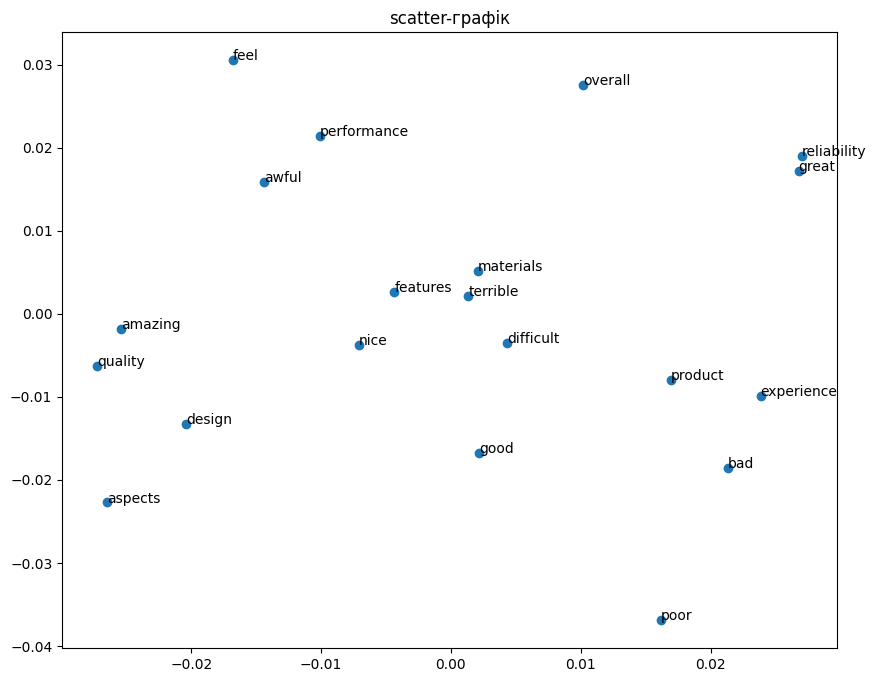

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words_20 = model.wv.index_to_key[:20]
wv_20 = model.wv[words_20]

pca = PCA(n_components=2)
result = pca.fit_transform(wv_20)

plt.figure(figsize=(10,8))
plt.scatter(result[:,0], result[:,1])
plt.title('scatter-графік')
for i, w in enumerate(list(words_20)):
    plt.annotate(w, xy=(result[i,0], result[i, 1]))

plt.savefig('scatter-графік.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import gensim.downloader as gdl
glove = gdl.load('glove-wiki-gigaword-100')

In [9]:
print(glove.most_similar("good", topn=5))

[('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762274742126), ('kind', 0.8288268446922302), ('very', 0.8260800242424011)]


In [10]:
table = """ 
|Цільове слово|Близьке|Косинусна схожість|
|-|-|-|
"""
from IPython.display import Markdown as md

for word in words: 
    #print(model.wv.most_similar(word, topn=3))
    similars = ', '.join(map(str, [similar[0] for similar in glove.most_similar(word, topn=3)]))
    cos_similar = ', '.join(map(str, [round(similar[1], 2)for similar in glove.most_similar(word, topn=3)]))
    table += f"|{word}|{similars}|{cos_similar}|\n"
md(table)

 
|Цільове слово|Близьке|Косинусна схожість|
|-|-|-|
|good|better, sure, really|0.89, 0.83, 0.83|
|bad|worse, good, things|0.79, 0.77, 0.77|
|quality|excellent, standards, performance|0.76, 0.73, 0.72|
